# Módulo 05 — Introdução ao Deep Learning

**Objetivos de aprendizagem**

- Entender os fundamentos de redes neurais (perceptron, MLPs, funções de ativação, backpropagation);

- Experimentar arquiteturas básicas (MLP, CNN, RNN/LSTM) em dados sintéticos e de exemplo;

- Compreender regularização (L1/L2, Dropout), normalização (BatchNorm) e data augmentation (conceitos);

- Visualizar um bloco de Atenção multi-cabeças (base de Transformers) em um exemplo simples;

- Discutir desafios, limitações e princípios de governança/explicabilidade (XAI) de forma prática.



> **Observação**: As células a seguir foram pensadas para rodar em ambientes locais/colab. Caso alguma biblioteca não esteja instalada, execute a célula de instalação.


In [ ]:
#@title Checagem de ambiente (versões) e instalação opcional
import sys, platform
print("Python:", sys.version)
print("Plataforma:", platform.platform())

# Instalação opcional (descomente se precisar)
# !pip install -U tensorflow keras scikit-learn matplotlib numpy


## 1. O que é Deep Learning?

Deep Learning utiliza **redes neurais com múltiplas camadas** para aprender **representações hierárquicas** dos dados.
Diferentemente de técnicas clássicas que dependem de *feature engineering* manual, redes profundas podem **aprender as características** diretamente de dados brutos (imagens, texto, áudio etc.).

**Três fatores-chave para o sucesso recente:**

1. **Big Data** (abundância de dados)

2. **Hardware** (GPUs/TPUs)

3. **Algoritmos** (otimizadores modernos + truques de treino)



## 2. Fundamentos de Redes Neurais

- **Perceptron**: soma ponderada + viés → função de ativação.

- **Funções de ativação**: introduzem não linearidade (p.ex.: Sigmoid, Tanh, ReLU, Softmax).

- **MLPs (Redes multicamadas)**: camadas densas empilhadas (entrada → ocultas → saída).

- **Backpropagation**: ajusta pesos/vieses via **gradiente** da função de perda.



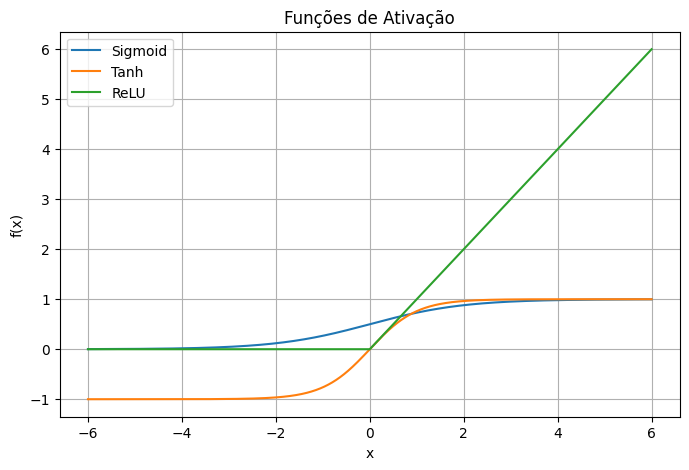

In [ ]:
# Visualização de funções de ativação
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 1000)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

plt.figure(figsize=(8,5))
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")
plt.title("Funções de Ativação")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

## 3. MLP — Classificação em dados 2D (make_moons)

Vamos treinar uma **MLP** (rede densa) em dados sintéticos **não lineares** (dataset *moons*). Incluímos **Dropout**, **BatchNormalization** e **L2** para mostrar técnicas de **regularização** e estabilização do treino.



In [ ]:
# Dados 2D sintéticos + MLP com Keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Gerando dados
X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
display (X)

array([[ 1.58230488,  0.36687604],
       [ 0.32765354,  0.98236569],
       [ 0.48826986, -0.2467652 ],
       ...,
       [-0.98227246,  0.6850586 ],
       [ 0.78917116, -0.82716661],
       [ 0.26339306,  0.06283128]])

In [ ]:
# Modelo MLP
inputs = keras.Input(shape=(2,))
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

hist = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=64, verbose=0)

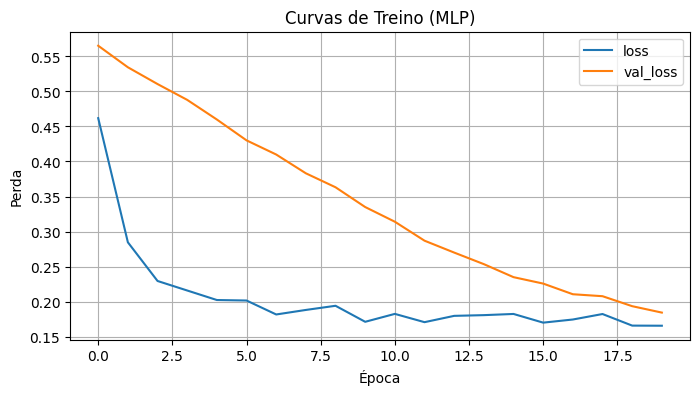

In [ ]:
# Curvas de treino
plt.figure(figsize=(8,4))
plt.plot(hist.history["loss"], label="loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.title("Curvas de Treino (MLP)")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend(); plt.grid(True); plt.show()



In [ ]:
# Avaliação
y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       197
           1       0.95      0.92      0.94       203

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



In [ ]:
import pandas as pd

df_resultados = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

print(df_resultados.head(50))  # mostra só os 20 primeiros


    Real  Previsto
0      1         1
1      1         1
2      0         0
3      1         1
4      0         0
5      1         1
6      0         0
7      0         0
8      1         1
9      1         1
10     1         1
11     0         0
12     0         0
13     0         0
14     1         1
15     1         1
16     0         0
17     1         1
18     1         1
19     1         1
20     0         0
21     1         1
22     1         1
23     0         0
24     1         1
25     1         1
26     1         0
27     1         1
28     0         0
29     0         1
30     0         0
31     1         0
32     1         1
33     0         1
34     0         0
35     0         0
36     0         0
37     1         1
38     0         0
39     1         1
40     0         0
41     0         0
42     0         0
43     0         0
44     1         1
45     0         0
46     0         0
47     0         0
48     1         1
49     1         1


In [ ]:
acertos = (y_pred == y_test).sum()
erros = (y_pred != y_test).sum()
total = len(y_test)

print(f"Acertos: {acertos}")
print(f"Erros: {erros}")
print(f"Toral : {total}")
print(f"Acurácia: {acertos/total:.2%}")


Acertos: 375
Erros: 25
Toral : 400
Acurácia: 93.75%


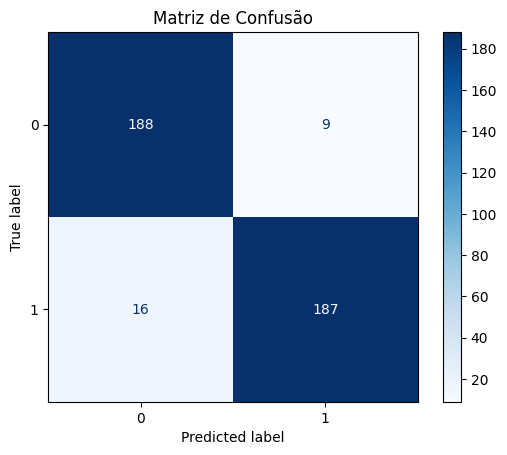

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()


# Explicação do Código `perceptron_train`

```python
import numpy as np

def perceptron_train(X, y, eta=0.1, epochs=10):
    # y deve ser -1 ou +1
    w = np.zeros(X.shape[1])
    b = 0.0
    for _ in range(epochs):
        for xi, di in zip(X, y):
            u = np.dot(w, xi) + b
            yi = 1 if u > 0 else -1
            w += eta * (di - yi) * xi
            b += eta * (di - yi)
    return w, b
```

---

## 📌 Explicação passo a passo

### 1. Inicialização dos pesos
```python
w = np.zeros(X.shape[1])
b = 0.0
```
- `w`: vetor de pesos, começa em zeros.  
- `X.shape[1]`: número de atributos (features).  
- `b`: viés, começa em 0.  
👉 Define a "reta inicial" (no caso 2D) ou hiperplano que o perceptron vai ajustar.

---

### 2. Loop de treino
```python
for _ in range(epochs):
    for xi, di in zip(X, y):
```
- `epochs`: quantas vezes percorre todo o dataset.  
- `zip(X, y)`: percorre cada exemplo `xi` e seu rótulo `di`.  
- Atualização é **online** (a cada exemplo).

---

### 3. Cálculo da saída
```python
u = np.dot(w, xi) + b
yi = 1 if u > 0 else -1
```
- `u = w·x + b`: combinação linear.  
- `yi`: saída prevista pelo perceptron (função degrau).  
  - Se `u > 0` → prevê **+1**.  
  - Se `u <= 0` → prevê **-1**.

---

### 4. Atualização dos pesos
```python
w += eta * (di - yi) * xi
b += eta * (di - yi)
```
- Fórmula do Perceptron:  
  \[ w \leftarrow w + \eta (d - y)x \]  
  \[ b \leftarrow b + \eta (d - y) \]

- `di - yi`:  
  - Se **acertou** → 0 → não muda.  
  - Se **errou** → ajusta pesos e viés.

- `eta`: taxa de aprendizado → controla intensidade da correção.

---

### 5. Retorno
```python
return w, b
```
- Retorna os **pesos finais** `w` e o **viés** `b`.  
- Representam o **hiperplano aprendido** pelo perceptron.

---

✅ **Resumo**:  
O código implementa o **Perceptron clássico**.  
- Inicializa pesos em 0.  
- Percorre os dados várias vezes (epochs).  
- Para cada exemplo, prevê a saída.  
- Se erra, ajusta pesos e viés.  
- Retorna os parâmetros finais que definem a fronteira de decisão.

In [ ]:
import numpy as np

def perceptron_train(X, y, eta=0.1, epochs=10):
    # y deve ser -1 ou +1
    w = np.zeros(X.shape[1])
    b = 0.0
    for _ in range(epochs):
        for xi, di in zip(X, y):
            u = np.dot(w, xi) + b
            yi = 1 if u > 0 else -1
            w += eta * (di - yi) * xi
            b += eta * (di - yi)
    return w, b


## 4. CNN — Classificação de dígitos (sklearn digits 8x8)

Para evitar dependências de download, usamos o dataset **Digits (8×8)** do *scikit-learn*.

Transformamos as imagens para formato `(8, 8, 1)` e treinamos uma **CNN** compacta.



In [ ]:
# CNN com dataset Digits (8x8) do scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
digits = load_digits()
X = digits.images  # (n, 8, 8)
y = digits.target  # 0..9

# Normaliza para [0,1] e reshape para (8,8,1)
X = (X / 16.0).astype("float32")
X = np.expand_dims(X, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:

num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

model_cnn = keras.Sequential([
    layers.Conv2D(16, (3,3), activation="relu", input_shape=(8,8,1), padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

model_cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist_cnn = model_cnn.fit(X_train, y_train_cat, validation_split=0.2, epochs=15, batch_size=64, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


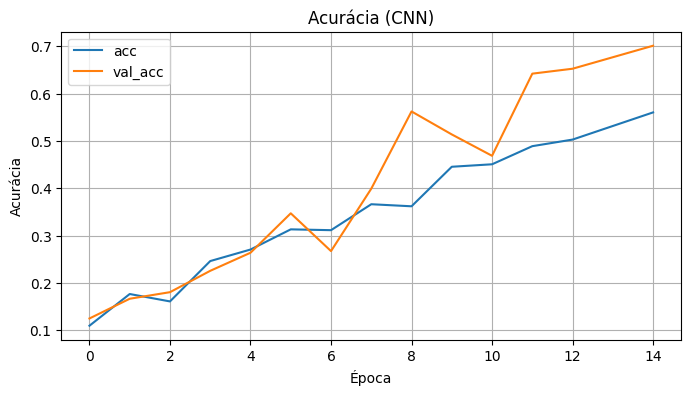

In [ ]:
# Curvas
plt.figure(figsize=(8,4))
plt.plot(hist_cnn.history["accuracy"], label="acc")
plt.plot(hist_cnn.history["val_accuracy"], label="val_acc")
plt.title("Acurácia (CNN)")
plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.legend(); plt.grid(True); plt.show()

# Explicação: MaxPooling e Teste do Modelo CNN

## 🔹 O que é MaxPooling?

No modelo CNN, temos a camada:

```python
layers.MaxPooling2D((2,2))
```

- **Pooling** é uma operação usada em redes convolucionais para **reduzir a dimensão espacial** (altura × largura) das ativações.
- **MaxPooling2D (2,2)** divide a imagem em janelas de 2×2 e **pega o valor máximo** de cada janela.

### Vantagens:
- **Reduz dimensionalidade**, deixando a rede mais leve.
- **Remove redundâncias** → mantém apenas os padrões mais fortes.
- **Maior robustez a pequenas translações/ruídos**.

### Exemplo:
Aplicando MaxPooling 2×2 em uma matriz 4×4:

\[
\begin{bmatrix}
1 & 3 & 2 & 1 \\
0 & 4 & 1 & 2 \\
5 & 6 & 2 & 0 \\
1 & 2 & 3 & 4
\end{bmatrix}
\;\;\;\;\Rightarrow\;\;\;\;
\begin{bmatrix}
4 & 2 \\
6 & 4
\end{bmatrix}
\]


---

## 🔹 O que é o Teste (`evaluate`)?

```python
test_loss, test_acc = model_cnn.evaluate(X_test, y_test_cat, verbose=0)
print(f"Acurácia no teste: {test_acc:.4f}")
```

- Após o treinamento, precisamos medir o desempenho em **dados nunca vistos**.
- `evaluate` retorna:
  - `test_loss`: valor da função de perda no conjunto de teste.
  - `test_acc`: acurácia no conjunto de teste.

👉 Esse passo verifica se o modelo **generaliza bem** ou se apenas decorou o treino (overfitting).


---

## 🔹 Visualização de Previsões

```python
idx = np.random.choice(len(X_test), 8, replace=False)
X_sample, y_true = X_test[idx], y_test[idx]
y_pred = np.argmax(model_cnn.predict(X_sample), axis=1)
```

- Seleciona **8 imagens aleatórias** do conjunto de teste.
- O modelo faz previsões (`predict`) → vetor de probabilidades.
- `argmax` pega a classe mais provável.
- As imagens são plotadas com:
  - `T:` (True) → classe real.
  - `P:` (Pred) → classe prevista.

👉 Isso permite validar visualmente o desempenho do modelo.


---

## ✅ Resumo

- **MaxPooling**: reduz tamanho e mantém os valores mais fortes (janela 2×2 → maior valor).  
- **Teste (`evaluate`)**: mede perda e acurácia em dados novos.  
- **Visualização**: mostra algumas previsões comparadas com os rótulos reais.

Acurácia no teste: 0.7139
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


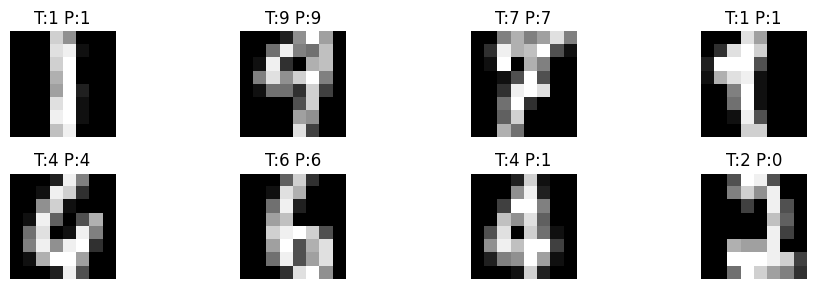

In [ ]:
test_loss, test_acc = model_cnn.evaluate(X_test, y_test_cat, verbose=0)
print(f"Acurácia no teste: {test_acc:.4f}")

# Visualização de previsões em algumas imagens
idx = np.random.choice(len(X_test), 8, replace=False)
X_sample, y_true = X_test[idx], y_test[idx]
y_pred = np.argmax(model_cnn.predict(X_sample), axis=1)

plt.figure(figsize=(10,3))
for i, (img, yt, yp) in enumerate(zip(X_sample, y_true, y_pred)):
    plt.subplot(2,4,i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"T:{yt} P:{yp}")
plt.tight_layout(); plt.show()

## 5. RNN/LSTM — Previsão de série temporal (seno)

Criamos uma série **senoidal** com ruído e treinamos uma **LSTM** para prever o próximo valor.

Este exemplo demonstra como RNNs/LSTMs capturam **dependências temporais**.



# LSTM em Série Temporal Sintética (Seno)

## 1. Geração da Série
Criamos uma série temporal composta por:
- Um senoide principal: `sin(0.02t)`
- Um harmônico: `0.3·sin(0.05t + 1.0)`
- Ruído gaussiano: `0.1·N(0,1)`

Isso gera um sinal periódico com **duas frequências** e **ruído**, ideal para testar previsões.

---

## 2. Janela Deslizante (Supervisionamento)
A função `make_windows` transforma a série em pares entrada/saída:

- Para cada índice *i*:  
  - **Entrada (X[i])** = 30 pontos consecutivos  
  - **Saída (y[i])** = ponto seguinte

Formato dos dados:
- `X`: `(n_amostras, 30, 1)`
- `y`: `(n_amostras,)`

---

## 3. Divisão Temporal
- **Treino/validação**: primeiros 80% da série
- **Teste**: últimos 20%

⚠️ Observação: usar `validation_split=0.2` com `fit` embaralha os dados.  
Em séries temporais, prefira `shuffle=False` ou defina manualmente um **conjunto de validação sequencial**.

---

## 4. Arquitetura da LSTM
```python
model_lstm = keras.Sequential([
    layers.Input(shape=(WINDOW,1)),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(1)
])
```

- **LSTM(32)**: lê a sequência de 30 passos e gera um estado final
- **Dense(1)**: previsão do próximo valor
- **Loss**: MSE  
- **Otimizador**: Adam

---

## 5. Treinamento
- **Épocas**: 20  
- **Batch**: 32  
- **Histórico**: curvas de `loss` e `val_loss` monitoram **convergência** e **overfitting**.

---

## 6. Avaliação
- Previsão **one-step ahead** no conjunto de teste.
- Gráfico compara valores reais e previstos nos primeiros 200 pontos.

Se as curvas coincidem bem, a LSTM capturou as frequências principais mesmo sob ruído.

---

## 7. Boas Práticas e Melhorias

1. **Validação temporal correta**  
   Definir manualmente `X_val, y_val` como a parte final do treino.

2. **Escalonamento**  
   Usar `StandardScaler` ou `MinMaxScaler` para estabilizar o treinamento.

3. **Regularização**  
   - EarlyStopping (`patience=10`)  
   - Dropout dentro da LSTM (`recurrent_dropout=0.1`)

4. **Baselines para comparação**  
   - Naive (`ŷ_t = y_{t-1}`)  
   - Média móvel  
   - ARIMA / Prophet

5. **Exploração de hiperparâmetros**  
   - Variação do tamanho da janela (`20, 40, 60`)  
   - LSTM empilhadas (`return_sequences=True` + segunda LSTM)

6. **Previsão multi-step**  
   - **Iterativa**: realimenta previsões (erro acumula)  
   - **Direta**: saída vetorial (Dense com `h` passos)  
   - **Seq2Seq**: Encoder-Decoder para horizontes longos

---

## TL;DR
- O código implementa uma **LSTM simples para previsão de 1 passo** em série temporal senoidal com ruído.  
- A abordagem funciona bem como **prova de conceito**, mas em aplicações reais é necessário:  
  - validar de forma temporal,  
  - comparar com baselines,  
  - ajustar janela e arquitetura,  
  - considerar previsões multi-step.  

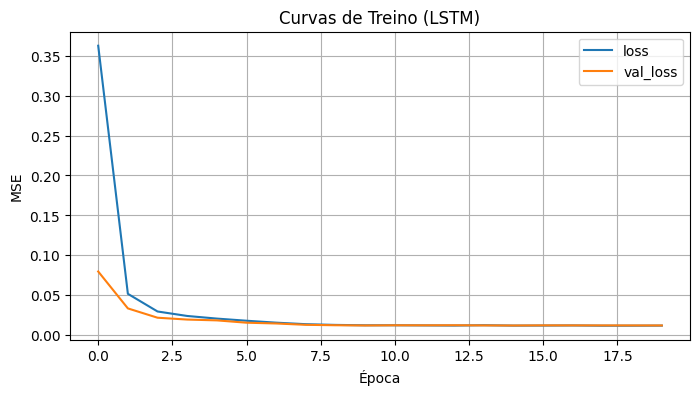

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


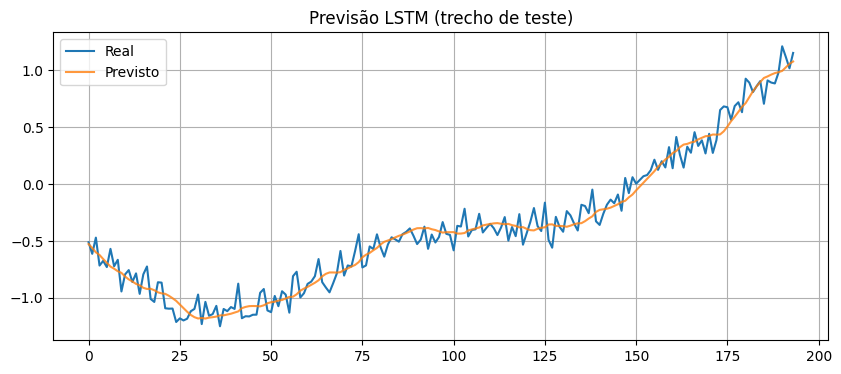

In [1]:
# LSTM em série temporal sintética (seno)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Série senoidal com ruído
np.random.seed(42)
T = 1000
t = np.arange(T)
series = np.sin(0.02 * t) + 0.3*np.sin(0.05*t + 1.0) + 0.1*np.random.randn(T)

# Gera janelas (lookback) para predição do próximo passo
def make_windows(series, window=20):
    X, y = [], []
    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    X = np.array(X)[:, :, np.newaxis]  # (n, window, 1)
    y = np.array(y)
    return X, y

WINDOW = 30
X, y = make_windows(series, WINDOW)
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

model_lstm = keras.Sequential([
    layers.Input(shape=(WINDOW,1)),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")
hist_lstm = model_lstm.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)

plt.figure(figsize=(8,4))
plt.plot(hist_lstm.history["loss"], label="loss")
plt.plot(hist_lstm.history["val_loss"], label="val_loss")
plt.title("Curvas de Treino (LSTM)")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend(); plt.grid(True); plt.show()

# Avaliação simples
pred = model_lstm.predict(X_test).ravel()
plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label="Real")
plt.plot(pred[:200], label="Previsto", alpha=0.8)
plt.title("Previsão LSTM (trecho de teste)")
plt.legend(); plt.grid(True); plt.show()

## 6. Transformers — Demonstração de Atenção Multi-Cabeças

A base dos **Transformers** é o mecanismo de **Atenção**. Abaixo, usamos `tf.keras.layers.MultiHeadAttention` para ilustrar **autoatenção** em uma sequência sintética.

> Objetivo: Mostrar a API e a forma de **consultar pesos de atenção** (quando possível), não otimizar desempenho.



# Demonstração de Atenção Multi-Head

## 1. Dados de entrada
```python
np.random.seed(0)
inputs = np.random.randn(2, 5, 8).astype("float32")
```
- **Batch = 2** sequências  
- **Timesteps = 5** (cada sequência tem 5 posições)  
- **Dimensão = 8** por vetor  

Ou seja, a entrada tem formato `(2, 5, 8)`.

---

## 2. Bloco de Atenção
```python
inp = keras.Input(shape=(5,8))
attn = layers.MultiHeadAttention(num_heads=2, key_dim=8, output_shape=8)
x = attn(inp, inp, use_causal_mask=False)  # self-attention
```
- `MultiHeadAttention(num_heads=2, key_dim=8)` cria 2 **cabeças de atenção**.
- `inp` é usado como **queries**, **keys** e **values** → isso é **self-attention**.
- `output_shape=8`: saída projetada de volta para dimensão 8.
- `use_causal_mask=False`: cada posição pode olhar para todas as outras (não restrito ao passado).

---

## 3. Residual + Normalização
```python
x = layers.LayerNormalization()(x + inp)
```
- Soma residual (`x + inp`) preserva a informação original.
- `LayerNormalization` estabiliza o treinamento.

---

## 4. Feed-Forward (MLP)
```python
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(8)(x)
```
- Projeção não linear: 8 → 16 → 8.
- Ativação ReLU no meio, depois volta para dimensão 8.

---

## 5. Outro Residual + Normalização
```python
x = layers.LayerNormalization()(x + inp)
```
- Mais um skip connection com normalização, como no **Transformer Encoder**.

---

## 6. Construção do Modelo
```python
model_attn = keras.Model(inp, x)
out = model_attn(inputs)
print("Saída de atenção:", out.shape)
```
- Entrada: `(batch=2, seq_len=5, d_model=8)`
- Saída: `(2, 5, 8)`

O modelo mantém a mesma forma da entrada, mas cada posição agora está **contextualizada** pela atenção com todas as outras.

---

## 7. Observação Importante
- O `MultiHeadAttention` do Keras (por padrão) **não retorna os pesos de atenção** (matriz `attention_scores`).  
- Para visualização, seria necessário:
  - Usar `return_attention_scores=True` (se disponível),  
  - ou implementar uma camada customizada de atenção.

---

## TL;DR
Esse script implementa:
1. **Self-Attention Multi-Head**  
2. **Residual + Normalização**  
3. **Feed-Forward (MLP)**  
4. **Outro Residual + Normalização**  

👉 É praticamente um **bloco Encoder do Transformer**, aplicado em uma sequência pequena.  

In [2]:
# Demonstração simples de Atenção (MultiHeadAttention)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Sequência sintética:  batch=2, timesteps=5, dim=8
np.random.seed(0)
inputs = np.random.randn(2, 5, 8).astype("float32")

inp = keras.Input(shape=(5,8))
attn = layers.MultiHeadAttention(num_heads=2, key_dim=8, output_shape=8)
x = attn(inp, inp, use_causal_mask=False)  # self-attention
x = layers.LayerNormalization()(x + inp)    # residual + norm
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(8)(x)
x = layers.LayerNormalization()(x + inp)
model_attn = keras.Model(inp, x)

out = model_attn(inputs)
print("Saída de atenção:", out.shape)

# Observação: Alguns backends não expõem os pesos de atenção diretamente.
# Em implementações custom, pode-se obter 'attention_scores' para visualização.


Saída de atenção: (2, 5, 8)


## 7. Regularização, Normalização e Data Augmentation

### Principais técnicas

- **L1/L2**: penalizam pesos grandes (controlam complexidade do modelo);

- **Dropout**: desativa aleatoriamente neurônios durante o treino;

- **Batch Normalization**: normaliza ativações por *batch*, acelerando e estabilizando o treino;

- **Data Augmentation**: cria variações artificiais (sobretudo em visão computacional) para ampliar o dataset efetivo.



Abaixo, um **exemplo conceitual** de *augmentation* para imagens. (Não roda nothing por si só sem imagens; é uma referência.)



In [ ]:
# Exemplo conceitual de Data Augmentation (referência)
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
#                              zoom_range=0.1, horizontal_flip=True)
# datagen.fit(X_train_imagens)  # onde X_train_imagens é seu dataset de treino
#
# model.fit(datagen.flow(X_train_imagens, y_train, batch_size=32),
#           validation_data=(X_val, y_val), epochs=20)


## 8. Desafios, Limitações e XAI

- **Dados rotulados**: custo/tempo para anotar grandes coleções.

- **Custo computacional**: treino e inferência podem ser caros.

- **Caixa-preta**: difícil interpretar decisões (cresce o foco em **XAI**).

- **Riscos éticos/sociais**: viés algorítmico, *deepfakes*, privacidade, segurança.



### Exemplo (opcional) — Saliency Map em CNN

A seguir, um exemplo de **saliency map** (gradiente da saída em relação à entrada) para uma imagem do dataset `digits`. Útil para **inspecionar** quais pixels influenciam a predição.



In [ ]:
# Saliency map simples para uma amostra do Digits (CNN treinada acima)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

try:
    # Usa model_cnn e X_test do bloco anterior
    img = X_test[0:1]  # (1, 8, 8, 1)
    img_var = tf.convert_to_tensor(img)

    # Índice da classe predita
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        preds = model_cnn(img_var)
        top_class = tf.argmax(preds[0])
        top_score = preds[0, top_class]

    grads = tape.gradient(top_score, img_var)  # dY/dX
    saliency = tf.reduce_max(tf.abs(grads), axis=-1).numpy().squeeze()  # (8,8)

    plt.figure(figsize=(8,3))
    plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap="gray"); plt.axis("off"); plt.title("Imagem")
    plt.subplot(1,3,2); plt.imshow(saliency, cmap="hot"); plt.axis("off"); plt.title("Saliency")
    plt.subplot(1,3,3); plt.imshow(img.squeeze(), cmap="gray");
    plt.imshow(saliency, cmap="hot", alpha=0.6); plt.axis("off"); plt.title("Overlay")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Para executar este bloco, rode antes a célula da CNN com as variáveis `model_cnn` e `X_test` definidas.")
    print("Erro:", e)

## 9. Encerramento e Próximos Passos

**Resumo**:

- Vimos MLP, CNN e LSTM em exemplos práticos, além de um bloco de Atenção;

- Discutimos regularização, normalização e *augmentation*;

- Introduzimos noções de XAI (saliency map) e governança.



**Próximos passos sugeridos**:

- Aprofundar em **Transformers** (tokenização, máscaras, *positional encoding*, *fine-tuning*);

- Experimentar **Evidently** para *drift* de dados e **Prometheus/Grafana** para métricas em produção;

- Estudar governança (LGPD/GDPR), MLOps e segurança no ciclo de vida do modelo.

